<a href="https://colab.research.google.com/github/YRMESHRAM/Machine-Vision-Practical/blob/main/MV_P4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kaustubhdikshit/neu-surface-defect-database")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'neu-surface-defect-database' dataset.
Path to dataset files: /kaggle/input/neu-surface-defect-database


In [2]:
import os

# List contents of the downloaded dataset path
print(f"Contents of {path}:")
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')

Contents of /kaggle/input/neu-surface-defect-database:
neu-surface-defect-database/
    NEU-DET/
        validation/
            annotations/
                scratches_246.xml
                patches_258.xml
                crazing_241.xml
                patches_267.xml
                crazing_270.xml
                pitted_surface_256.xml
                pitted_surface_265.xml
                pitted_surface_287.xml
                crazing_265.xml
                rolled-in_scale_288.xml
                pitted_surface_294.xml
                crazing_300.xml
                pitted_surface_269.xml
                scratches_284.xml
                patches_251.xml
                patches_283.xml
                pitted_surface_250.xml
                pitted_surface_255.xml
                patches_265.xml
                crazing_296.xml
                inclusion_288.xml
                scratches_265.xml
                patches_292.xml
                pitted_surface_248.xml
                pi

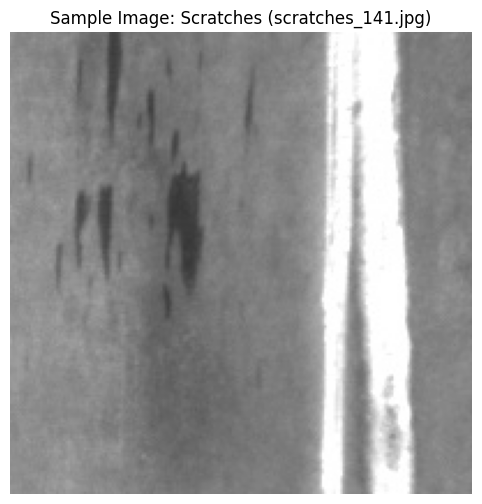

Sample image loaded from: /kaggle/input/neu-surface-defect-database/NEU-DET/train/images/scratches/scratches_141.jpg


In [3]:
import cv2
import matplotlib.pyplot as plt
import os

# Define paths
base_path = os.path.join(path, "NEU-DET", "train", "images")
defect_type = "scratches"
image_folder = os.path.join(base_path, defect_type)

# Get a list of all image files in the 'scratches' folder
image_files = [f for f in os.listdir(image_folder) if f.endswith('.jpg')]

if image_files:
    # Select the first image for demonstration
    sample_image_name = image_files[0]
    sample_image_path = os.path.join(image_folder, sample_image_name)

    # Read the image using OpenCV
    img = cv2.imread(sample_image_path)

    # Convert BGR to RGB for matplotlib display
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Display the image
    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.title(f'Sample Image: {defect_type.capitalize()} ({sample_image_name})')
    plt.axis('off')
    plt.show()
else:
    print(f"No image files found in {image_folder}")

print(f"Sample image loaded from: {sample_image_path}")

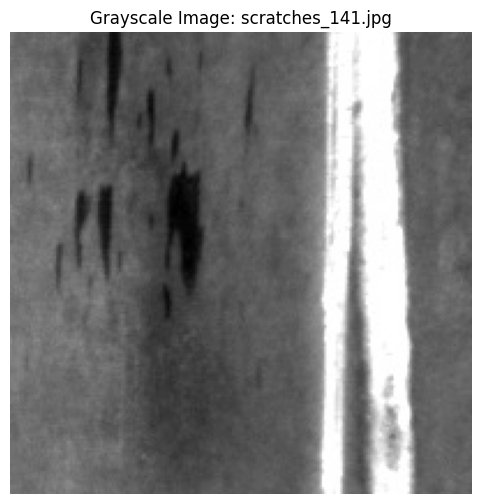

Image converted to grayscale.


In [4]:
# Convert the image to grayscale
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Display the grayscale image
plt.figure(figsize=(8, 6))
plt.imshow(img_gray, cmap='gray')
plt.title(f'Grayscale Image: {sample_image_name}')
plt.axis('off')
plt.show()

print("Image converted to grayscale.")

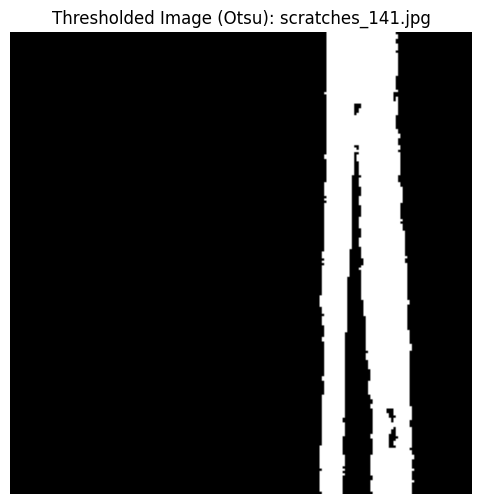

Image thresholded using Otsu's method.


In [5]:
# Apply Otsu's thresholding to convert the grayscale image to a binary image
# Otsu's method automatically determines the optimal threshold value.
_, img_thresholded = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Display the thresholded image
plt.figure(figsize=(8, 6))
plt.imshow(img_thresholded, cmap='gray')
plt.title(f'Thresholded Image (Otsu): {sample_image_name}')
plt.axis('off')
plt.show()

print("Image thresholded using Otsu's method.")

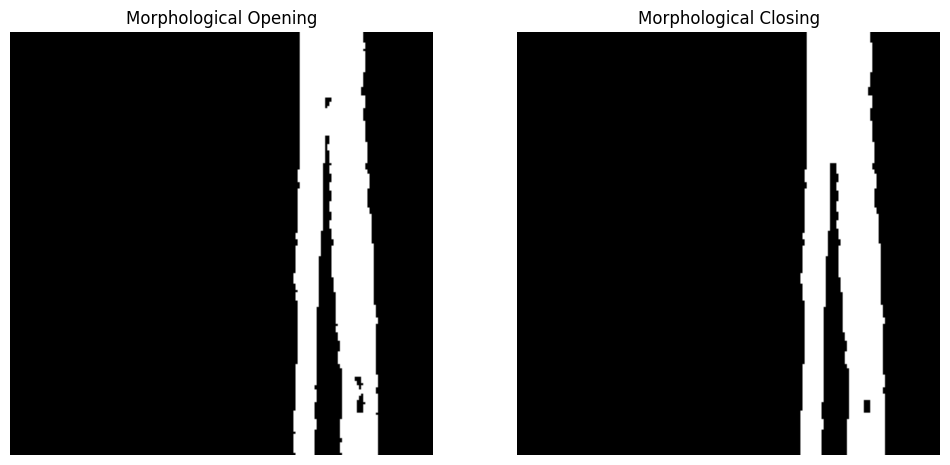

Morphological operations (opening and closing) applied.


In [6]:
# Define a kernel for morphological operations
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

# Apply morphological 'opening' to remove small objects (noise) outside the defect
img_opened = cv2.morphologyEx(img_thresholded, cv2.MORPH_OPEN, kernel, iterations=1)

# Apply morphological 'closing' to close small holes inside the defect
img_closed = cv2.morphologyEx(img_opened, cv2.MORPH_CLOSE, kernel, iterations=1)

# Display the results of morphological operations
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_opened, cmap='gray')
plt.title('Morphological Opening')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_closed, cmap='gray')
plt.title('Morphological Closing')
plt.axis('off')
plt.show()

print("Morphological operations (opening and closing) applied.")

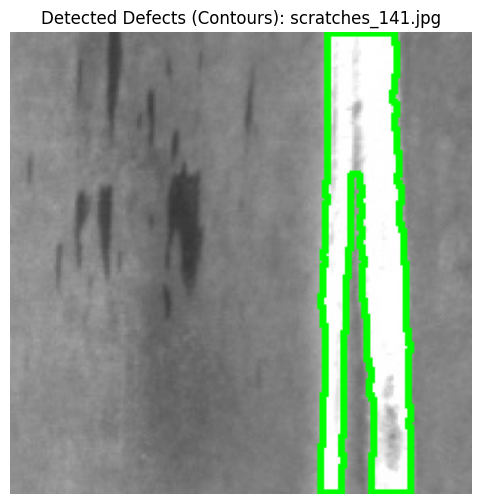

Found 1 contours.


In [7]:
# Find contours in the morphologically closed image
# cv2.CHAIN_APPROX_SIMPLE compresses horizontal, vertical, and diagonal segments
# and leaves only their end points. E.g., a rectangle will have 4 points.
contours, _ = cv2.findContours(img_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Create a blank image to draw contours on
contour_img = img.copy()

# Draw detected contours on the original image
cv2.drawContours(contour_img, contours, -1, (0, 255, 0), 2) # Green color, thickness 2

# Display the image with contours
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))
plt.title(f'Detected Defects (Contours): {sample_image_name}')
plt.axis('off')
plt.show()

print(f"Found {len(contours)} contours.")